[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github//planetlabs/notebooks/blob/master/jupyter-notebooks/workflows/introduction_to_analysis_apis/image_metadata_headers_pip.ipynb)


# Lookup Scene Traceability Information for ARPS data in the Planet Insights Platform

This notebook covers how to download image metadata header information from the Planet Insights Platform. 

To demonstrate this, we will use the Statistical API to retrieve index values from the scene_mask band, and the BYOC API to retrieve the ARPS QA header, which can be used to map the scene index values to scene ids, and subsequently derive the actual collection time of any given pixel.

The BYOC API can only be used with collections **you own**, not sandbox data or other collections shared with you, so you must have created an ARPS collection in order to utilize this notebook.

For an introduction to the Subscriptions API, which can be used to obtain ARPS data, refer to the [Subscriptions API - Data Collection Delivery](https://github.com/planetlabs/notebooks/blob/master/jupyter-notebooks/api_guides/subscriptions_api/subscriptions_to_data_collection.ipynb) notebook.

For an introduction to ARPS data, refer to the [Intro to ARPS data in Planet Insights Platform](https://github.com/planetlabs/notebooks/blob/master/jupyter-notebooks/use_cases/calculate_water_extent_analysis_ready_planetscope/calculate_water_extent_analysis_ready_planetscope.ipynb) notebook.

For an introduction to the Statistical API, refer to the [First Steps in accessing Satellite Imagery with Sentinel Hub APIs](https://github.com/planetlabs/notebooks/blob/master/jupyter-notebooks/workflows/introduction_to_analysis_apis/introduction_to_analysis_apis.ipynb) notebook.


In [ ]:
%matplotlib inline

import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from rasterio.io import MemoryFile
import requests

from sentinelhub import (
    CRS,
    DataCollection,
    SentinelHubStatistical,
    SentinelHubCatalog,
    SentinelHubBYOC,
    SentinelHubSession,
    BBox,
    bbox_to_dimensions,
)

## ARPS Data Structure

ARPS Tiles are constructed from a composite of many different PlanetScope Scenes. In the example below, a total of 10 PS ortho scenes from three separate strips were used to construct the tile image. 

![Scene Traceability](arps_scene_traceability.webp)

Information on what pixels came from what scenes is stored in the ARPS QA dataset. Each footprint is associated with a unique integer value that is linked to a scene identifier (i.e., Itemtype/sceneID) embedded as metadata in the QA geotiff.

For more information on ARPs, refer to the [ARPS Technical Specification](https://docs.planet.com/data/imagery/arps/techspec/)

## Credentials

The Sentinel Hub Python SDK requires a `client_id` and a `client_secret`. To obtain your `client_id` & `client_secret`, you need to navigate to your [account manager](insights.planet.com/account/), and in the **User Settings**, create a new OAuth client. More detailed instructions can be found in our [authentication documentation](https://docs.planet.com/develop/authentication/).

Once you have your `client_id` & `client_secret`, it is recommended to configure a new profile in your Sentinel Hub Python package. Instructions on how to configure your Sentinel Hub Python package can be found [in the documentation](https://sentinelhub-py.readthedocs.io/en/latest/configure.html). This is useful as changes to the config class in your notebook are usually only temporary and by saving the configuration to your profile, you don't have to generate new credentials or overwrite the default profile every time you run a new Jupyter Notebook.

The following cell checks for an existing default configuration. If none is found, you will be prompted for your credentials, which you can then optionally save.

In [ ]:
from sentinelhub import SHConfig

# Authenticate with the Sentinel Hub Python SDK; See docs: https://sentinelhub-py.readthedocs.io/en/latest/configure.html and https://docs.planet.com/develop/authentication
# If no default configuration detected, enter a client ID and secret to authenticate. These can be obtained by creating an OAuth client here: https://insights.planet.com/account
config = SHConfig()
if not config.sh_client_id or not config.sh_client_secret:
    from getpass import getpass
    print('No credentials found, please provide the OAuth client ID and secret.')
    config.sh_client_id = getpass('Client ID: ')
    config.sh_client_secret = getpass('Client Secret: ')
    ## Uncomment the following lines to save your credentials to a configuration
    # config.save() 
    # print(f'Credentials saved to {SHConfig.get_config_location()}')
else:
    print(f'Using credentials stored here: {SHConfig.get_config_location()}')


Using credentials stored here: /Users/torben.barsballe/.config/sentinelhub/config.toml


## Collection Configuration

Use of the BYOC API requires a collection you own. Update this section with details coorresponding to one of your ARPS collections.

In [ ]:
# This is the collection ID for your ARPS collection
collection_id = "fd05d036-f0e5-48ac-bf7a-5a4ab7b00efb"
data_collection = DataCollection.define_byoc(collection_id)

# Enter a BBOX for your AOI
sample_aoi = (-123.38346, 48.420365, -123.368483, 48.428257)

start_date = "2023-05-01T00:00:00Z"
end_date = "2023-06-01T00:00:00Z"

#Resolution of ARPS
resolution = 3
sample_bbox = BBox(bbox=sample_aoi, crs=CRS.WGS84)
sample_size = bbox_to_dimensions(sample_bbox, resolution=resolution)

print(f"Image shape at {resolution} m resolution: {sample_size} pixels")

Image shape at 3 m resolution: (371, 291) pixels


## Extract Timeseries

This example evalscript calculates NDWI from ARPS, similar to the example in the [Intro to ARPS data in Planet Insights Platform](https://github.com/planetlabs/notebooks/blob/master/jupyter-notebooks/use_cases/calculate_water_extent_analysis_ready_planetscope/calculate_water_extent_analysis_ready_planetscope.ipynb) notebook.

The scene_mask band has been added as a seperate output. Since this is a discrete value, the default `mean` statistic won't be very useful.

To account for this, we can add a 50th percentile (median) calculation when making the Statistical API request to find the most common pixel value, corresponding to the scene which coveres the most area of the AOI, and use that index to look up the scene id from the metadata. This approach works best with relatively small AOIs - less than the size of a typical PlanetScope scene.
For a complete listing of all scene indexes within the AOI, you could instead use a histogram with `"bins": list(range(255))` - the `lowEdge` of each nonzero bin will correspond to a scene index found within the AOI.

In [90]:
ndwi_time_eval = """
//VERSION=3

function setup() {
    return {
        input: [
            {
                bands: [
                    "green",
                    "nir",
                    "cloud_mask",
                    "scene_mask",
                    "dataMask"
                ]
            }
        ],
        output: [
            {
                id: "default",
                bands: 1,
                sampleType: "FLOAT32"
            },
            {
                id: "scenes",
                bands: 1,
                sampleType: "INT16"
            },
            {
                id: "dataMask",
                bands: 1
            }
        ]
    };
}

function evaluatePixel(sample) {

    var noCloudMask = 0
    if (sample.cloud_mask==1){
        noCloudMask = 1
    }
    const clear = sample.dataMask * noCloudMask;
    var ndwi = (sample.green - sample.nir ) / (sample.green  + sample.nir );

    return {
        default: [ndwi],
        scenes: [sample.scene_mask],
        dataMask: [clear]
    };
}
"""

In [151]:
def get_stats(collection, eval, interval):
    # Stat API calc that calculates NDWI within a date range and the AOI for all available imagery
    request = SentinelHubStatistical(
        aggregation=SentinelHubStatistical.aggregation(
            evalscript=eval,
            time_interval=interval,
            aggregation_interval="P1D",
            size=sample_size,
        ), # Percentiles calculation to find the median scene index
        calculations={
            "scenes": {
                "statistics": {
                    "B0": {
                        "percentiles": {
                            "k": [50],
                        }
                    }
                }
            }
        },
        input_data=[SentinelHubStatistical.input_data(collection, maxcc=1)],
        bbox=sample_bbox,
        config=config,
    )
    return request.get_data()[0]

In [152]:
result =  get_stats(data_collection, ndwi_time_eval, (start_date, end_date))
# Sample the first result. Note the 50th percentile value
result['data'][0]

{'interval': {'from': '2023-05-01T00:00:00Z', 'to': '2023-05-02T00:00:00Z'},
 'outputs': {'default': {'bands': {'B0': {'stats': {'min': -0.7426335215568542,
      'max': 0.1428571492433548,
      'mean': -0.2328091594230953,
      'stDev': 0.17339357128568147,
      'sampleCount': 107961,
      'noDataCount': 2210}}}},
  'scenes': {'bands': {'B0': {'stats': {'min': 122.0,
      'max': 122.0,
      'mean': 122.0,
      'stDev': 0.0,
      'sampleCount': 107961,
      'noDataCount': 2210,
      'percentiles': {'50.0': 122.0}}}}}}}

## Metadata Lookup

### Locating ARPS Tiles with the Catalog API

**Note**: If your AOI spans multiple ARPS tiles, catalog_search will return more than one result.
This edge case is not accounted for in this notebook, but you could handle it by discarding the tile that overlaps your BBOX the least, or by splitting your BBOX according to the ARPS tile boundaries, as retrieved from the Catalog API, and making seperate Statistical APIs for each sub-AOI.

In [20]:
def catalog_search(sh_config: SHConfig, collection: DataCollection, bbox: BBox, start_time: str, end_time: str):
    """
    Simple wrapper around SentinelHubCatalog.search, with more basic options

    :param sh_config: SHConfig object with client credentials
    :param collection: SentinelHub Collection
    :param bbox: Bounding Box
    :param start_time: ISO time string
    :param end_time: ISO time string
    :return: Iterator of search results
    """

    catalog = SentinelHubCatalog(config=sh_config)

    return catalog.search(
        collection,
        bbox=bbox,
        time=(start_time, end_time)
    )

In [44]:
first_tile = catalog_search(config, data_collection, sample_bbox, '2023-05-01T00:00:00Z', '2023-05-01T23:59:59Z').__next__()

### Extracting ARPS Metadata with the BYOC API

The BYOC API includes a [download endpoint](https://docs.sentinel-hub.com/api/latest/reference/#tag/byoc_tile/operation/getByocTileFile) for downloading files directly.

We just need the header data of the QA asset, so we can do a range read to download just what we need.
The [BYOC Tile Info](https://docs.sentinel-hub.com/api/latest/reference/#tag/byoc_tile/operation/getByocCollectionTileById) response lists each asset for a tile, and the size of the header for that asset, so that we know how much of the file we need to read.

In [45]:
byoc = SentinelHubBYOC(config=config)
tile_info = byoc.get_tile(data_collection, first_tile["id"])
tile_info["additionalData"]["filesMetadata"]

{'analysis_ready_ps_qa': {'headerSize': 3529,
  'etag': '"6d43d5451da22d0ae8a759fbe4965efb"'},
 'analysis_ready_ps_sr': {'headerSize': 3433,
  'etag': '"6fde2880ba998419e26cb7229fe88875-22"'}}

The header will be downloaded as binary data, so we can use `rasterio` to extract the tags in a human-readable format.

In [24]:
def get_arps_metadata(sh_config: SHConfig, collection: DataCollection, item_id: str) -> dict:
    """
    Use the BYOC to extract the scene mask mapping metadata from an ARPS QA tile
    Note: Consumes (a small amount of) PUs

    :param sh_config: SH Configuration and credentials
    :param collection: SH Collection
    :param item_id: Catalog id of the ARPS tile, e.g. from a Catalog API search.
    :return: A dict containing the tags from the COG header of the matching ARPS tile
    """

    byoc = SentinelHubBYOC(config=sh_config)

    # Use the BYOC API to extract the file name and header size
    tile_info = byoc.get_tile(collection, item_id)
    target_file = "analysis_ready_ps_qa"
    file_name = tile_info["path"].split("/")[-1].replace("(BAND)", target_file)
    source_len = tile_info["additionalData"]["filesMetadata"][target_file]["headerSize"]

    download_url = f"https://services.sentinel-hub.com/api/v1/byoc/collections/{collection.collection_id}/tiles/{item_id}/files/{file_name}"

    # Do a range-read of just the header size to get only the metadata
    session = SentinelHubSession(config=sh_config)
    headers = {"Range": f"bytes=0-{source_len - 1}",
               "Authorization": f"Bearer {session.token['access_token']}"}
    response = requests.get(download_url, headers=headers, stream=True)

    bytes = response.content

    # Use rasterio to parse the tags from the header
    with MemoryFile(bytes) as memfile:
        with memfile.open() as dataset:
            tags = dataset.tags()

    return tags

In [47]:
metadata = get_arps_metadata(config, data_collection, first_tile["id"])
metadata

{'CREATED': '2024-11-08T17:03:40Z',
 'PERCENTAGE_CLEAR': '32.18',
 'PIPELINE_VERSION': '1.0.0',
 'PS_SCENE_IDS[LAYER_2_VALUE]': 'PSScene/20230501_181740_08_24bc[122]\nPSScene/20230501_181758_49_2458[207]\nNone[119]',
 'RUN_TYPE': 'backfill',
 'SCENE_IDS[LAYER_2_VALUE]': 'PSScene/20230501_181740_08_24bc[122]\nPSScene/20230501_181758_49_2458[207]\nNone[119]',
 'SCENE_SOLAR_AZIMUTH[LAYER_2_VALUE]': '135.6[122]\n134.6[207]\nNone[119]',
 'SCENE_SOLAR_ELEVATION[LAYER_2_VALUE]': '49.6[122]\n49.1[207]\nNone[119]',
 'AREA_OR_POINT': 'Area'}

## Retrieving Collection time from Scene 

In [49]:
def parse_scene_mask(scene_mask: str) -> dict:
    """
    Convert the raw SCENE_IDS[LAYER_2_VALUE] metadata value to a map of LAYER_2_VALUE: Scene_ID
    :param scene_mask:
    :return: A mapping of the pixel values from the scene_mask layer to the corresponding Scene IDs
    """
    entries = scene_mask.split('\n')
    scene_map = {}
    for entry in entries:
        scene, idx = entry.split("[")

        scene = scene.replace("PSScene/", "")

        idx = idx.replace("]", "")

        scene_map[idx] = scene

    return scene_map


In [ ]:
scene_map = parse_scene_mask(metadata['SCENE_IDS[LAYER_2_VALUE]'])
# Retrieve the median scene index over our AOI, which we calculated earlier
scene_index = str(int(result['data'][0]['outputs']['scenes']['bands']['B0']['stats']['percentiles']['50.0']))
scene_id = scene_map[scene_index]
scene_id

'20230501_181740_08_24bc'

## Collection time

We can use the scene id to calculate a more precise collection time for our BBOX

PlanetScope Scene IDs have a fixed structure, which encodes a [variety of useful information](https://docs.planet.com/data/imagery/planetscope/#product-naming).
For this use case, we are just interested in the first 15 characters of the id, which encode the acquisition date (YYYYMMDD) and acquisition time (HHMMSS) in UTC.

In [56]:
def datetime_from_scene_id(scene_id: str) -> datetime:
    """
    Convert a PSScene Id to the corresponding acquisition time (in UTC)
    :param scene_id:
    :return: Acquisition time
    """
    scene_tokens = scene_id.split("_")
    ymd = scene_tokens[0]
    hms = scene_tokens[1]

    capture_date = datetime(year=int(ymd[0:4]), month=int(ymd[4:6]), day=int(ymd[6:]), hour=int(hms[0:2]), minute=int(hms[2:4]), second=int(hms[4:]))

    return capture_date

In [59]:
str(datetime_from_scene_id(scene_id))

'2023-05-01 18:17:40'

# Aggregate results

Bringing everything together, we can update our statistical results with accurate collection times

In [145]:
values = []

for r in result['data']:
    ndwi = r["outputs"]['default']['bands']['B0']['stats']['mean']
    tile_date = r['interval']['from']
    if ndwi == "NaN":
        print(f"NaN result for {tile_date}, skipping...")
        continue
    
    scene_index = str(int(r['outputs']['scenes']['bands']['B0']['stats']['percentiles']['50.0']))    
    tile_info = list(catalog_search(config, data_collection, sample_bbox, tile_date, tile_date[0:10] + 'T23:59:59Z'))
    tile_id = tile_info[0]["id"]
    tile_metadata = get_arps_metadata(config, data_collection, tile_id)
    try:
        scene_id = parse_scene_mask(tile_metadata['SCENE_IDS[LAYER_2_VALUE]'])[scene_index]
        scene_date = datetime_from_scene_id(scene_id)

        values.append({"date": scene_date, "ndwi": ndwi})
    except KeyError as e:
        print(f"No matching scene for {tile_date}, index {scene_index}. Found {len(tile_info)} matching tile(s)")



No matching scene for 2023-05-09T00:00:00Z, index 173. Found 1 matching tile(s)
NaN result for 2023-05-16T00:00:00Z, skipping...
NaN result for 2023-05-18T00:00:00Z, skipping...


In [153]:
data_df = pd.DataFrame(values)
data_df

,date,ndwi
0,2023-05-01 18:17:40,-0.232809
1,2023-05-02 18:16:35,-0.201494
2,2023-05-03 18:16:29,-0.243971
3,2023-05-07 18:14:54,-0.199280
4,2023-05-13 18:06:53,-0.218207
5,2023-05-14 18:17:00,-0.209383
6,2023-05-15 18:48:26,-0.196516
7,2023-05-19 18:12:06,-0.214750
8,2023-05-20 18:20:08,-0.227569
9,2023-05-24 18:18:51,-0.273878


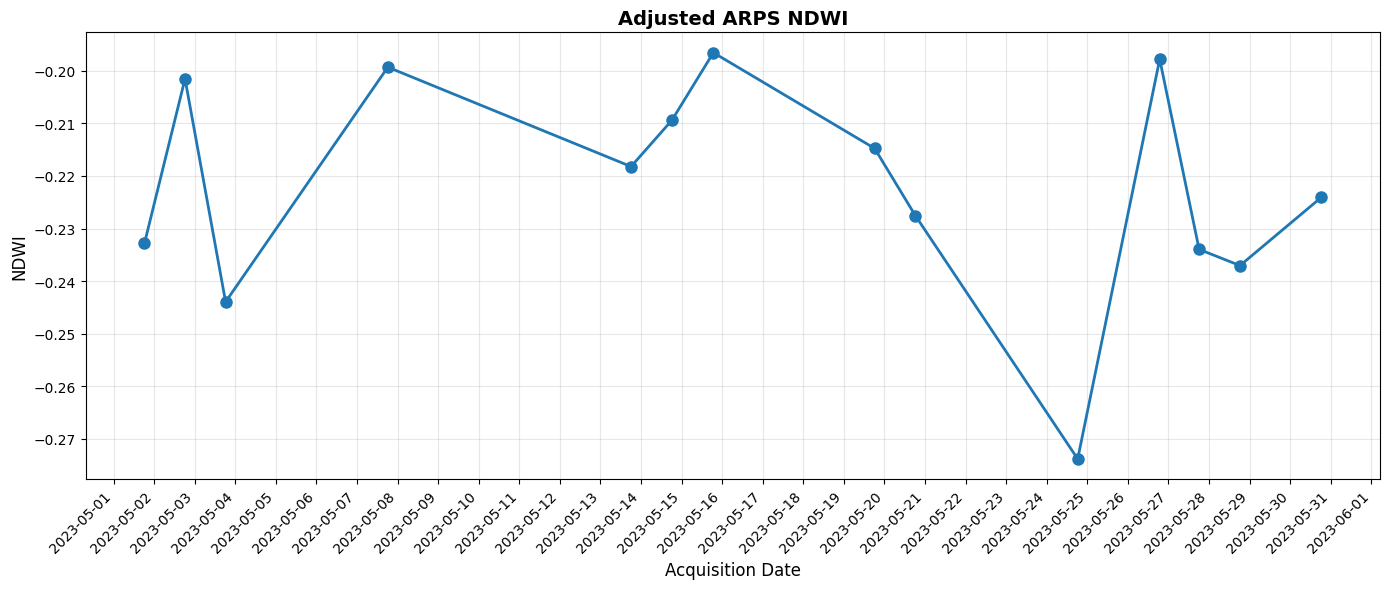

In [147]:
# Plot the NDWI timeseries with actual dates
import matplotlib.dates as mdates

plt.figure(figsize=(14, 6))
plt.plot(data_df['date'], data_df['ndwi'], marker='o', linestyle='-', linewidth=2, markersize=8)
plt.xlabel('Acquisition Date', fontsize=12)
plt.ylabel('NDWI', fontsize=12)
plt.title('Adjusted ARPS NDWI', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Set x-axis to show one tick per day
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()